# ML Lab-07: Ensemble Learning

**Aim**: To understand and implement Ensemble Learning techniques (Bagging, AdaBoost, Gradient Boosting, and Stacking) using the Breast Cancer dataset.

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print("Data shape:", X.shape)
print("Classes:", data.target_names)

Data shape: (569, 30)
Classes: ['malignant' 'benign']


In [2]:
def evaluate_model(model, name, plot_prefix):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    acc = accuracy_score(y_test, y_pred)
    print(f"--- {name} Performance ---")
    print(f"Accuracy: {acc:.4f}\n")
    print(classification_report(y_test, y_pred, target_names=data.target_names))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names)
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'Lab-07/outputs/{plot_prefix}_cm.png')
    plt.show()
    
    # ROC Curve
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(5, 4))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.title(f'{name} - ROC Curve')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.legend(loc="lower right")
        plt.tight_layout()
        plt.savefig(f'Lab-07/outputs/{plot_prefix}_roc.png')
        plt.show()
        
    return acc

## 2. Bagging Classifier

--- Bagging (Decision Tree) Performance ---
Accuracy: 0.9591

              precision    recall  f1-score   support

   malignant       0.95      0.94      0.94        63
      benign       0.96      0.97      0.97       108

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



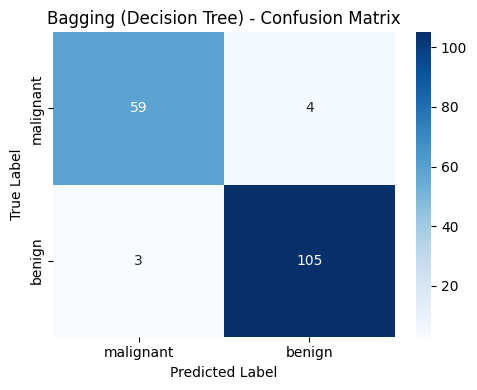

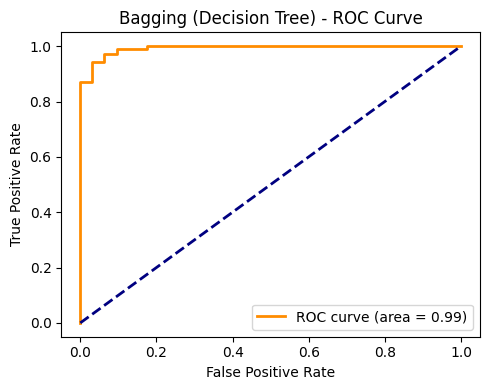

In [3]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bagging_clf = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=3), n_estimators=50, random_state=42)
bagging_clf.fit(X_train, y_train)

acc_bagging = evaluate_model(bagging_clf, "Bagging (Decision Tree)", "bagging")

## 3. AdaBoost Classifier

--- AdaBoost Performance ---
Accuracy: 0.9708

              precision    recall  f1-score   support

   malignant       0.95      0.97      0.96        63
      benign       0.98      0.97      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171



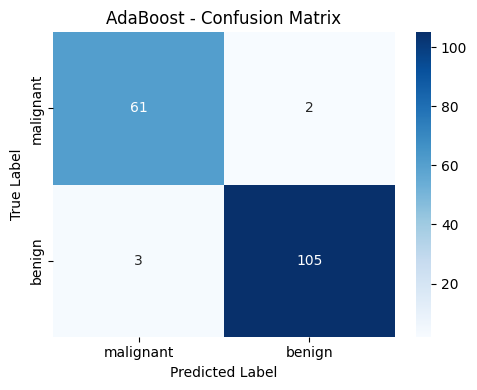

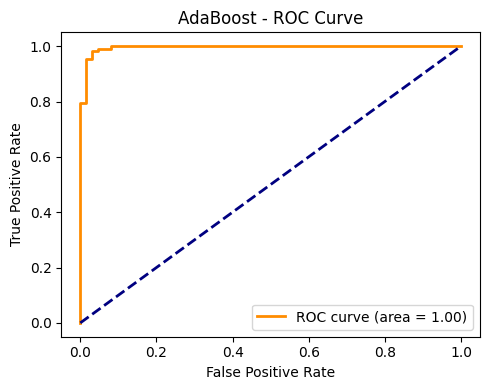

In [4]:
from sklearn.ensemble import AdaBoostClassifier

ada_clf = AdaBoostClassifier(n_estimators=50, random_state=42)
ada_clf.fit(X_train, y_train)

acc_ada = evaluate_model(ada_clf, "AdaBoost", "adaboost")

## 4. Gradient Boosting Classifier

--- Gradient Boosting Performance ---
Accuracy: 0.9591

              precision    recall  f1-score   support

   malignant       0.95      0.94      0.94        63
      benign       0.96      0.97      0.97       108

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



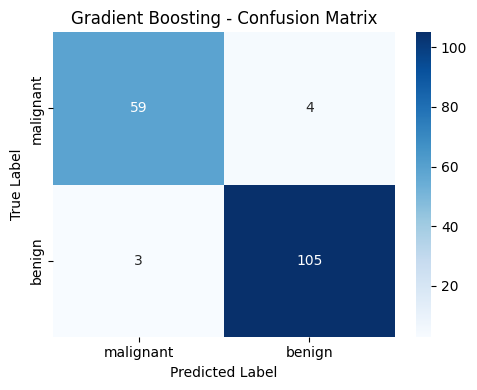

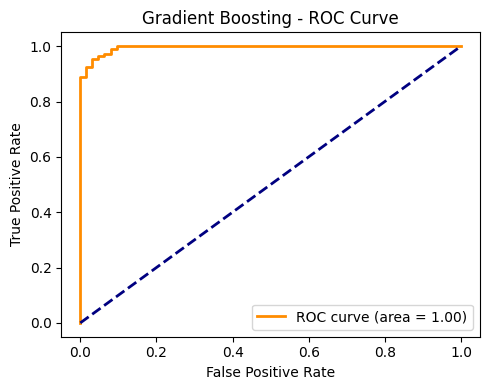

In [5]:
from sklearn.ensemble import GradientBoostingClassifier

gb_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_clf.fit(X_train, y_train)

acc_gb = evaluate_model(gb_clf, "Gradient Boosting", "gradient_boosting")

## 5. Stacking Classifier

--- Stacking Classifier Performance ---
Accuracy: 0.9708

              precision    recall  f1-score   support

   malignant       0.98      0.94      0.96        63
      benign       0.96      0.99      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



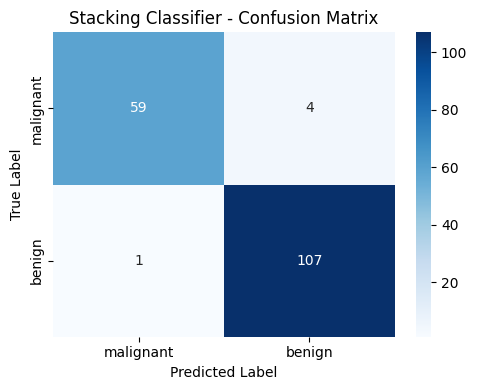

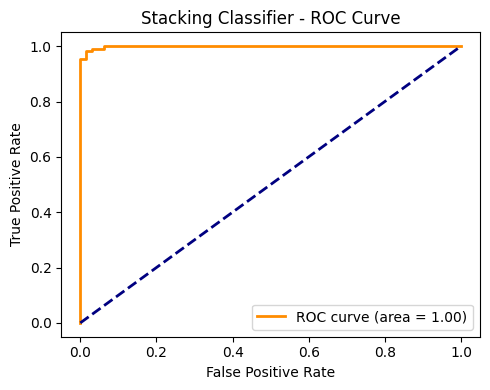

In [6]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

estimators = [
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('svc', SVC(probability=True, random_state=42))
]

stacking_clf = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stacking_clf.fit(X_train, y_train)

acc_stacking = evaluate_model(stacking_clf, "Stacking Classifier", "stacking")

## 6. Model Comparison

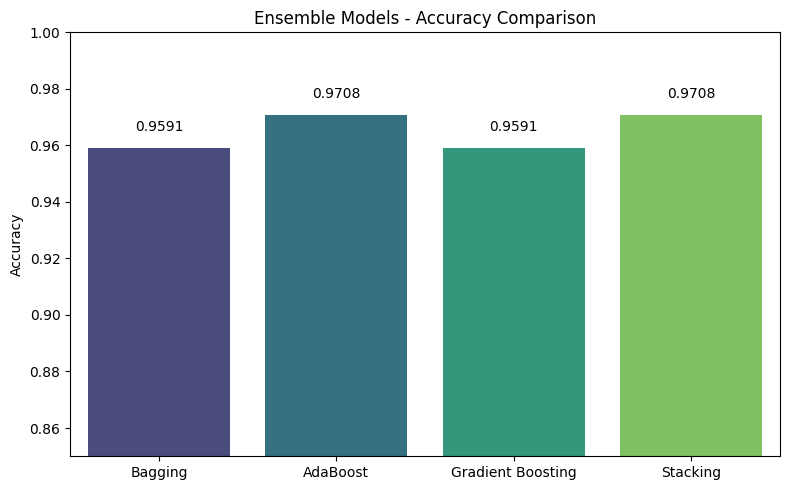

In [7]:
# Plotting accuracy comparison
models = ['Bagging', 'AdaBoost', 'Gradient Boosting', 'Stacking']
accuracies = [acc_bagging, acc_ada, acc_gb, acc_stacking]

plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=accuracies, palette="viridis", hue=models, legend=False)
plt.title('Ensemble Models - Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.85, 1.0)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center', va='bottom')
plt.tight_layout()
plt.savefig('Lab-07/outputs/accuracy_comparison.png')
plt.show()